# Run 6 — Analysis & Export

Loads saved checkpoints and result JSONs from run6. No training.

**Prerequisites**: run6 must be complete and results synced to Drive.
- `results/ablations/run6/_final_config.json`
- `results/ablations/run6/*.json`
- `models/run6/{winner_name}.pt`

| Section | What it does |
|---|---|
| §8a | Confusion matrix (needs GPU + checkpoint) |
| §8b | Class distribution (reads dataset only) |
| §8c | Shuttle coverage (reads dataset only) |
| §8d | Overfitting curves (reads JSONs only) |
| §8e | Diagnostic summary |
| §9  | Cross-attention weight visualization (needs cross-attn winner) |
| §10 | Per-shot inference export → `shot_type_predictions.json` |

In [18]:
import os, sys, json
from pathlib import Path

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    import zipfile
    if not (PROJECT_PATH / 'src').exists():
        with zipfile.ZipFile(DRIVE_ROOT / 'baddiev2_colab.zip') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)
else:
    PROJECT_PATH = Path('..').resolve()
    if not (PROJECT_PATH / 'src').exists():
        PROJECT_PATH = Path('.').resolve()
    DRIVE_ROOT = PROJECT_PATH
    if str(PROJECT_PATH) not in sys.path:
        sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

import src.config as _cfg

if IN_COLAB:
    _cfg.SS_CSV_ROOT        = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV       = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SKELETONS_GDINO = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES        = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.SS_SPLIT_JSON      = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'
    _cfg.MODELS_DIR         = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR        = DRIVE_ROOT / 'results'

    # dataset.py did `from ..config import SS_CSV_ROOT` — a value-binding import,
    # so reassigning _cfg.SS_CSV_ROOT above does NOT reach it. Patch its module
    # namespace directly. (The CSVs live on Drive, not in baddiev2_colab.zip.)
    import src.data.dataset as _ds_mod
    _ds_mod.SS_CSV_ROOT = _cfg.SS_CSV_ROOT
    assert Path(_ds_mod.SS_CSV_ROOT).exists(), (
        f"ShuttleSet CSVs not found at {_ds_mod.SS_CSV_ROOT} — "
        f"upload datasets/ShuttleSet/set/ to Drive."
    )

print(f'Project: {PROJECT_PATH}')
print(f'Colab: {IN_COLAB}')

Mounted at /content/drive
Project: /content/Baddiev2
Colab: True


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader, Dataset as _Dataset
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

from src.config import (
    FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, BONE_CHANNELS, COCO_SKELETON,
    SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)

N_CLASSES     = NUM_SHOT_TYPES
SHOT_WINDOW   = 32
BATCH_SIZE    = 64
ABLATION_DIR  = RESULTS_DIR / 'ablations' / 'run6'
MODELS_DIR_R6 = MODELS_DIR  / 'run6'

# Data directories — use local SSD copy on Colab if available, else Drive
if IN_COLAB:
    local_skel  = Path('/content/local_skel')
    local_shutt = Path('/content/local_shutt')
    import shutil
    if not local_skel.exists():
        print('Copying skeletons to local SSD...')
        shutil.copytree(_cfg.SS_SKELETONS_GDINO, local_skel)
    if not local_shutt.exists():
        print('Copying shuttles to local SSD...')
        shutil.copytree(_cfg.SS_SHUTTLES, local_shutt)
    SKEL_DIR  = local_skel
    SHUTT_DIR = local_shutt
else:
    SKEL_DIR  = _cfg.SS_SKELETONS_GDINO
    SHUTT_DIR = _cfg.SS_SHUTTLES

print(f'Device: {device}')
print(f'N_CLASSES: {N_CLASSES}')
print(f'Ablation dir: {ABLATION_DIR}')

Device: cpu
N_CLASSES: 15
Ablation dir: /content/drive/MyDrive/Baddiev2/results/ablations/run6


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────

class SinglePlayerWrapper(_Dataset):
    """Extract only the hitter's 17 joints from a dual-player dataset."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x, label = item[0], item[1]
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label


class SinglePlayerCrossAttnWrapper(_Dataset):
    """Hitter 17 joints + preserved shuttle tensor. For cross-attn + single player."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item     = self.ds[idx]
        x, label = item[0], item[1]
        shuttle  = item[2] if len(item) == 3 else torch.zeros(2, x.shape[1])
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label, shuttle


def collate_fn(batch):
    xs, labels = zip(*[(b[0], b[1]) for b in batch])
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)


def collate_fn_shuttle(batch):
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0]); labels.append(item[1])
        shuttles.append(item[2] if len(item) == 3 else torch.zeros(2, SHOT_WINDOW))
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)


def build_encoder(in_channels, num_nodes=NUM_NODES, pooling='mean'):
    single = (num_nodes == NUM_JOINTS)
    adj = GraphBuilder(use_inter_player=not single, single_player=single).build_adjacency().to(device)
    return STGCN(in_channels=in_channels, num_nodes=num_nodes, adjacency=adj,
                 num_layers=9, base_channels=64, embedding_dim=256,
                 temporal_kernel=9, dropout=0.3, pooling=pooling).to(device)


def compute_class_weights(dataset):
    labels  = [s.get('shot_type_idx') for s in dataset.samples
               if s.get('shot_type_idx') is not None]
    counts  = Counter(labels)
    total   = sum(counts.values())
    weights = torch.ones(N_CLASSES, dtype=torch.float32)
    for cls_id, cnt in counts.items():
        if cls_id < N_CLASSES:
            weights[cls_id] = total / (len(counts) * cnt)
    return weights


def evaluate(encoder, head, ds, cross_attn=None):
    cfn    = collate_fn_shuttle if cross_attn else collate_fn
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=cfn)
    encoder.eval(); head.eval()
    if cross_attn: cross_attn.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            xb, yb = batch[0], batch[1]; valid = yb >= 0
            if not valid.any(): continue
            emb = encoder(xb[valid].to(device))
            if cross_attn: emb = cross_attn(emb, batch[2][valid].to(device))
            all_logits.append(head(emb).cpu()); all_labels.append(yb[valid])
    if not all_logits: return 0.0, 0.0, np.array([]), np.array([]), {}
    logits = torch.cat(all_logits); y_true = torch.cat(all_labels).numpy()
    y_pred = logits.argmax(1).numpy()
    topk = {f'top{k}_acc': logits.topk(k,1).indices.eq(
                torch.tensor(y_true).unsqueeze(1)).any(1).float().mean().item()
            for k in [3, 5] if logits.shape[1] >= k}
    return (f1_score(y_true, y_pred, average='macro', zero_division=0),
            accuracy_score(y_true, y_pred), y_true, y_pred, topk)


print('Helpers defined.')

Helpers defined.


In [4]:
# ── Load final config + splits ────────────────────────────────────────────
with open(ABLATION_DIR / '_final_config.json') as f:
    fc = json.load(f)

# Derive fields the JSON doesn't store (training built fc dynamically; saved JSON is minimal).
fc.setdefault(
    'in_channels',
    (FEATURE_DIMS_WITH_HITTER if fc['use_hitter'] else FEATURE_DIMS)[fc['feature_layer']]
    + (BONE_CHANNELS if fc['use_bones'] else 0),
)
fc.setdefault('num_nodes', NUM_JOINTS if fc['single_player'] else NUM_NODES)
with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)

VAL_MATCH_NAMES = [
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
]
TRAIN_MATCHES = set(splits['train']) - set(VAL_MATCH_NAMES)
VAL_MATCHES   = set(VAL_MATCH_NAMES)
TEST_MATCHES  = set(splits['held_out'])
ALL_MATCHES   = set(splits['train']) | set(splits['held_out'])

print(f'Winner: {fc["winner_name"]}')
print(f'Config: {fc}')
print(f'Train: {len(TRAIN_MATCHES)}  Val: {len(VAL_MATCHES)}  Test: {len(TEST_MATCHES)}')

Winner: C3_shuttle_xattn
Config: {'winner_name': 'C3_shuttle_xattn', 'feature_layer': 'L3', 'single_player': True, 'use_hitter': False, 'use_bones': False, 'use_bbox_norm': False, 'pooling': 'mean', 'variable_window': False, 'use_shuttle': True, 'shuttle_fusion': 'cross_attn', 'in_channels': 14, 'num_nodes': 17}
Train: 17  Val: 2  Test: 2


## §8 — Diagnostic Analysis

Run cells in order — §8e depends on variables computed in §8a–§8d.

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Test samples: 1675
Accuracy:    0.7037
Macro-F1:    0.6462
Top-3 Acc: 0.9355
Top-5 Acc: 0.9760


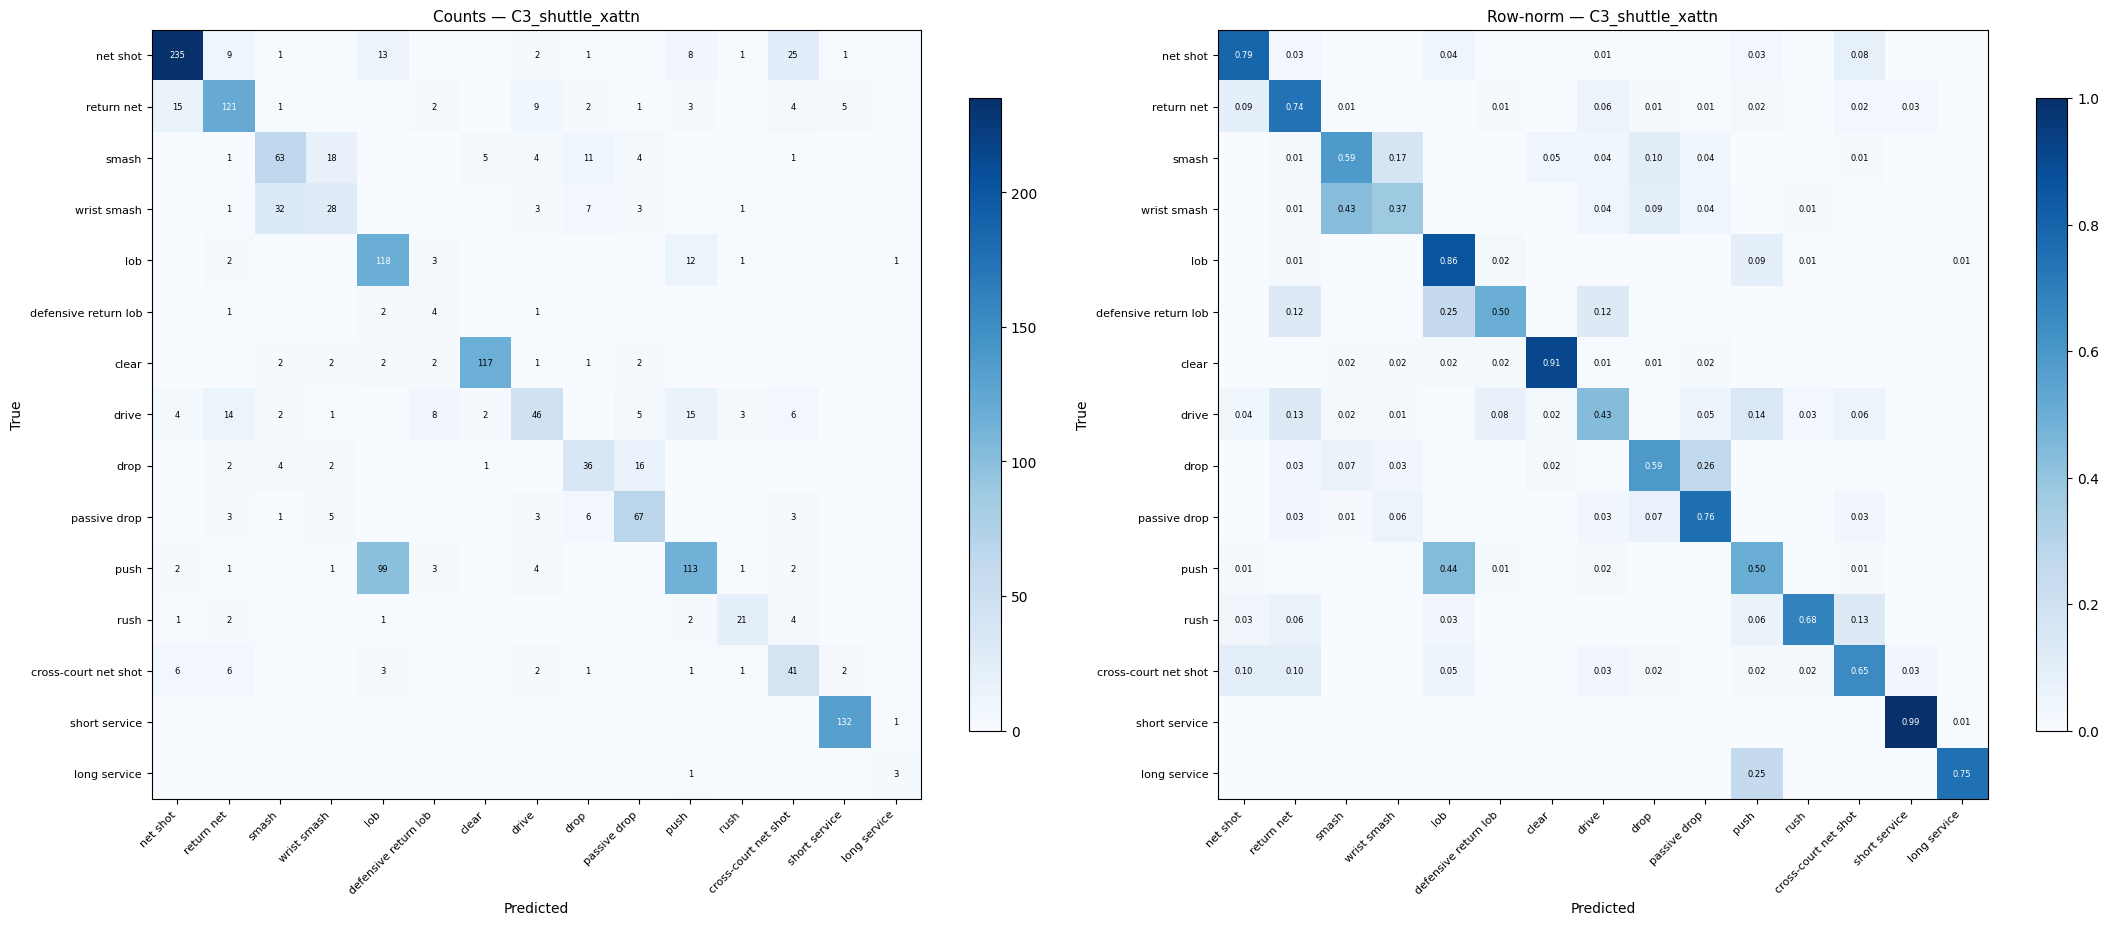

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/confusion_matrix_C3_shuttle_xattn.png

Top 15 confusion pairs:
  push                     → lob                      :   99 (44% of true push)
  wrist smash              → smash                    :   32 (43% of true wrist smash)
  net shot                 → cross-court net shot     :   25 (8% of true net shot)
  smash                    → wrist smash              :   18 (17% of true smash)
  drop                     → passive drop             :   16 (26% of true drop)
  drive                    → push                     :   15 (14% of true drive)
  return net               → net shot                 :   15 (9% of true return net)
  drive                    → return net               :   14 (13% of true drive)
  net shot                 → lob                      :   13 (4% of true net shot)
  lob                      → push                     :   12 (9% of true lob)
  smash                    → drop                     : 

In [19]:
# ── 8a — Confusion Matrix ─────────────────────────────────────────────────
# Loads checkpoint and runs inference on test set.

def _make_test_ds(fc, match_set):
    ds = ShuttleSetDataset(
        skeleton_dir=SKEL_DIR, shot_window=SHOT_WINDOW,
        feature_layer=fc['feature_layer'], load_shot_types=True, split=None,
        use_shuttle=fc['use_shuttle'], shuttle_dir=SHUTT_DIR if fc['use_shuttle'] else None,
        variable_window=fc['variable_window'], shuttle_fusion=fc['shuttle_fusion'],
        use_hitter=fc['use_hitter'], use_bones=fc['use_bones'], use_bbox_norm=fc['use_bbox_norm'],
    )
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in match_set]
    if fc['single_player']:
        if fc['use_shuttle'] and fc['shuttle_fusion'] == 'cross_attn':
            return SinglePlayerCrossAttnWrapper(ds)
        return SinglePlayerWrapper(ds)
    return ds


def _load_model(fc):
    ckpt = torch.load(MODELS_DIR_R6 / f'{fc["winner_name"]}.pt',
                      map_location=device, weights_only=True)
    enc  = build_encoder(fc['in_channels'], num_nodes=fc['num_nodes'], pooling=fc['pooling'])
    enc.load_state_dict(ckpt['enc']);  enc.eval()
    head = nn.Linear(256, N_CLASSES).to(device)
    head.load_state_dict(ckpt['head']); head.eval()
    ca = None
    if fc['use_shuttle'] and fc['shuttle_fusion'] == 'cross_attn':
        ca = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
        ca.load_state_dict(ckpt['ca']); ca.eval()
    return enc, head, ca


test_ds = _make_test_ds(fc, TEST_MATCHES)
enc, head, ca = _load_model(fc)
print(f'Test samples: {len(test_ds)}')

if len(test_ds) == 0:
    print("\n[!] ERROR: test_ds is empty. Ensure individual shot files exist in the match directories.")
    y_true = y_pred = np.array([])
else:
    _macro_f1, _accuracy, y_true, y_pred, topk = evaluate(enc, head, test_ds, ca)
    for k in [1, 3, 5]:
        if k == 1:
            print(f'Accuracy:    {_accuracy:.4f}')
            print(f'Macro-F1:    {_macro_f1:.4f}')
        else:
            print(f'Top-{k} Acc: {topk.get(f"top{k}_acc", 0):.4f}')

if len(y_true) > 0:
    _present = sorted(set(y_true) | set(y_pred))
    _lnames  = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'cls_{i}' for i in _present]
    _cm      = confusion_matrix(y_true, y_pred, labels=_present)
    _cm_norm = _cm.astype(float) / _cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
    for ax, data, title, fmt, vmax in [
        (ax1, _cm,      f'Counts — {fc["winner_name"]}', 'd',   None),
        (ax2, _cm_norm, f'Row-norm — {fc["winner_name"]}', '.2f', 1),
    ]:
        kw = {'vmin': 0, 'vmax': vmax} if vmax else {}
        im = ax.imshow(data, interpolation='nearest', cmap='Blues', **kw)
        ax.set_title(title, fontsize=11)
        ax.set_xticks(range(len(_lnames))); ax.set_yticks(range(len(_lnames)))
        ax.set_xticklabels(_lnames, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(_lnames, fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        thresh = data.max() * 0.5 if vmax is None else 0.5
        for i in range(len(_lnames)):
            for j in range(len(_lnames)):
                val = data[i, j]
                if (val > 0.005 if isinstance(val, float) else val > 0):
                    ax.text(j, i, format(val, fmt), ha='center', va='center',
                            fontsize=6, color='white' if val > thresh else 'black')
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    out = ABLATION_DIR / f'confusion_matrix_{fc["winner_name"]}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'Saved: {out}')

    _pairs = [(int(_cm[i,j]), float(_cm_norm[i,j]), _lnames[i], _lnames[j])
              for i in range(len(_lnames)) for j in range(len(_lnames))
              if i != j and _cm[i,j] > 0]
    _pairs.sort(reverse=True)
    print('\nTop 15 confusion pairs:')
    for cnt, frac, tc, pc in _pairs[:15]:
        print(f'  {tc:<24} → {pc:<24} : {cnt:4d} ({frac:.0%} of true {tc})')
else:
    print("\nSkipping confusion matrix due to empty predictions.")

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Train: 14933 labeled samples
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Val: 2077 labeled samples
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Test: 1627 labeled samples

ID   Shot Type                    Train    Tr%    Val   Test   Total
-----------------------------------------------------------------
0    net shot                      2872  19.2%    487    296    3655
1    return net                    1569  10.5%    221    163    1953
2    smash                         1158   7.8%    141    107    1406
3    wrist smash                    694   4.6%     99     75     868
4    lob                           2499  16.7%    410    137    3046
5    defensive return lob           136   0.9%     25      8     169
6    clear                          883   5.9%    140    129    1152
7    drive                

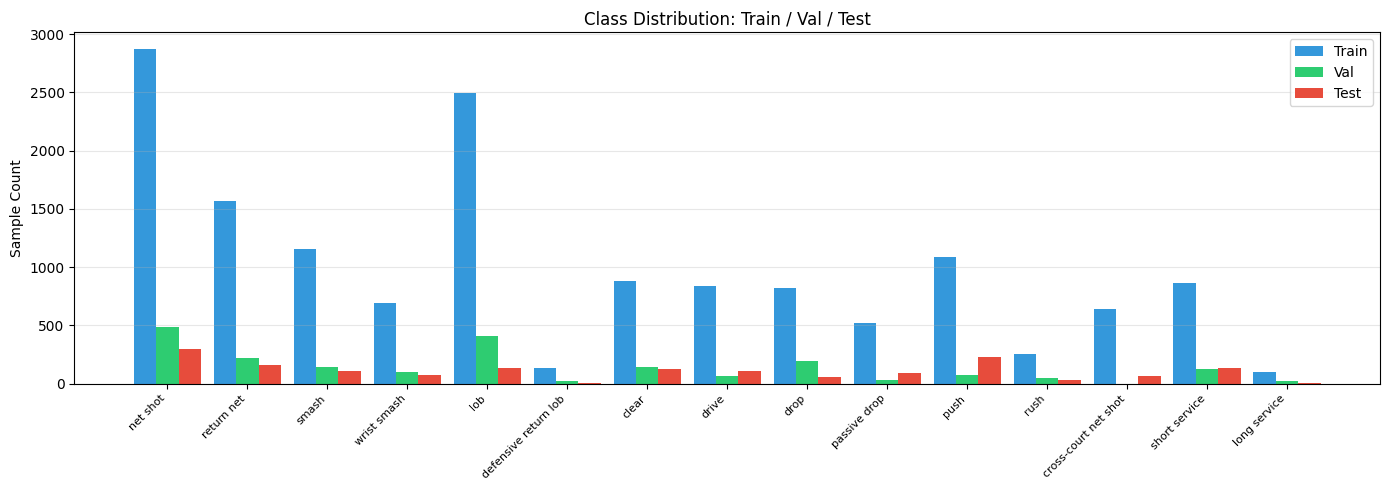

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/class_distribution.png


In [20]:
# ── 8b — Class Distribution ───────────────────────────────────────────────

def _label_counts(match_set, label):
    ds = ShuttleSetDataset(skeleton_dir=SKEL_DIR, shot_window=SHOT_WINDOW,
                           feature_layer='L2', load_shot_types=True, split=None)
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in match_set]
    labels = [s.get('shot_type_idx') for s in ds.samples if s.get('shot_type_idx') is not None]
    print(f'{label}: {len(labels)} labeled samples')
    return Counter(labels)

tr_cnt = _label_counts(TRAIN_MATCHES, 'Train')
va_cnt = _label_counts(VAL_MATCHES,   'Val')
te_cnt = _label_counts(TEST_MATCHES,  'Test')
all_cls = sorted(set(tr_cnt) | set(va_cnt) | set(te_cnt))
tot_tr  = sum(tr_cnt.values())

print(f'\n{"ID":<4} {"Shot Type":<26} {"Train":>7} {"Tr%":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
print('-' * 65)
for c in all_cls:
    nm = SHOT_TYPES[c] if c < len(SHOT_TYPES) else f'cls_{c}'
    tr = tr_cnt.get(c, 0); va = va_cnt.get(c, 0); te = te_cnt.get(c, 0)
    print(f'{c:<4} {nm:<26} {tr:>7} {tr/tot_tr*100:>5.1f}% {va:>6} {te:>6} {tr+va+te:>7}')
print(f'     {"TOTAL":<26} {tot_tr:>7} {"100%":>6} {sum(va_cnt.values()):>6} '
      f'{sum(te_cnt.values()):>6} {tot_tr+sum(va_cnt.values())+sum(te_cnt.values()):>7}')
print(f'\nImbalance: {max(tr_cnt.values())}/{min(tr_cnt.values())} = '
      f'{max(tr_cnt.values())/min(tr_cnt.values()):.1f}x')

fig, ax = plt.subplots(figsize=(14, 5))
_names = [SHOT_TYPES[c] if c < len(SHOT_TYPES) else f'cls_{c}' for c in all_cls]
_x = np.arange(len(all_cls)); _w = 0.28
ax.bar(_x-_w, [tr_cnt.get(c,0) for c in all_cls], _w, label='Train', color='#3498db')
ax.bar(_x,    [va_cnt.get(c,0) for c in all_cls], _w, label='Val',   color='#2ecc71')
ax.bar(_x+_w, [te_cnt.get(c,0) for c in all_cls], _w, label='Test',  color='#e74c3c')
ax.set_xticks(_x); ax.set_xticklabels(_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample Count'); ax.set_title('Class Distribution: Train / Val / Test')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
out = ABLATION_DIR / 'class_distribution.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Checking 2000 of 19470 samples...
With shuttle: 1739/2000 (87.0%)
Frame density (samples with data): mean=73.9%  median=81.2%


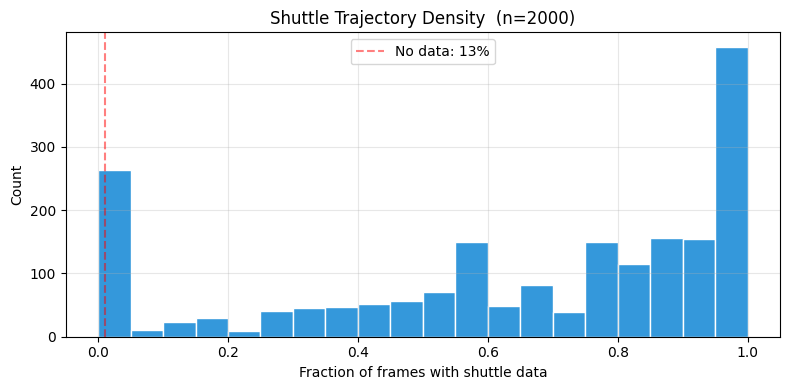

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/shuttle_coverage.png


In [21]:
# ── 8c — Shuttle Coverage ─────────────────────────────────────────────────

ds_sh = ShuttleSetDataset(
    skeleton_dir=SKEL_DIR, shot_window=SHOT_WINDOW, feature_layer='L2',
    load_shot_types=True, split=None,
    use_shuttle=True, shuttle_dir=SHUTT_DIR, shuttle_fusion='cross_attn',
)
ds_sh.samples = [s for s in ds_sh.samples
                 if isinstance(s, dict) and Path(s.get('skel_dir','')).name in ALL_MATCHES]

_n_check = min(len(ds_sh), 2000)
_rng = np.random.default_rng(42)
_idx = _rng.choice(len(ds_sh), size=_n_check, replace=False)
print(f'Checking {_n_check} of {len(ds_sh)} samples...')

_n_has = 0; _dens = []
for i in _idx:
    item = ds_sh[int(i)]
    if len(item) >= 3:
        sh = item[2].numpy() if hasattr(item[2], 'numpy') else item[2]
        has = np.any(sh[:2] != 0)
        _n_has += int(has)
        _dens.append(np.any(sh[:2] != 0, axis=0).mean())

_pct = _n_has / _n_check * 100
print(f'With shuttle: {_n_has}/{_n_check} ({_pct:.1f}%)')
_pos = np.array(_dens); _pos = _pos[_pos > 0]
if len(_pos) > 0:
    print(f'Frame density (samples with data): mean={_pos.mean():.1%}  median={np.median(_pos):.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.array(_dens), bins=20, color='#3498db', edgecolor='white')
ax.set_xlabel('Fraction of frames with shuttle data'); ax.set_ylabel('Count')
ax.set_title(f'Shuttle Trajectory Density  (n={_n_check})')
ax.axvline(x=0.01, color='red', ls='--', alpha=0.5, label=f'No data: {100-_pct:.0f}%')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
out = ABLATION_DIR / 'shuttle_coverage.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

Loaded 23 result files

Name                             Ep  FinalLoss  BestValF1   TestF1      Gap
------------------------------------------------------------------------------
A10_bones_bbox                   54     0.0335     0.6013   0.5923  +0.0090
A1_dual_L2                       25     0.1751     0.5686   0.5878  -0.0192
A2_dual_L3                       41     0.0414     0.5678   0.6097  -0.0419
A3_single_L2                     23     0.3253     0.5670   0.5967  -0.0297
A4_single_L3                     33     0.1416     0.5646   0.6102  -0.0456
A5_dual_L2_hitter                20     0.2714     0.5581   0.5902  -0.0321
A6_dual_L3_hitter                25     0.1885     0.5596   0.5917  -0.0321
A7_bones_only                    23     0.3303     0.6034   0.6054  -0.0020
A8_bones                         46     0.0636     0.5809   0.5998  -0.0189
A9_bbox_norm                     44     0.0595     0.5959   0.5877  +0.0082
B1_fixed_window                  31     0.1788     0.5632   0

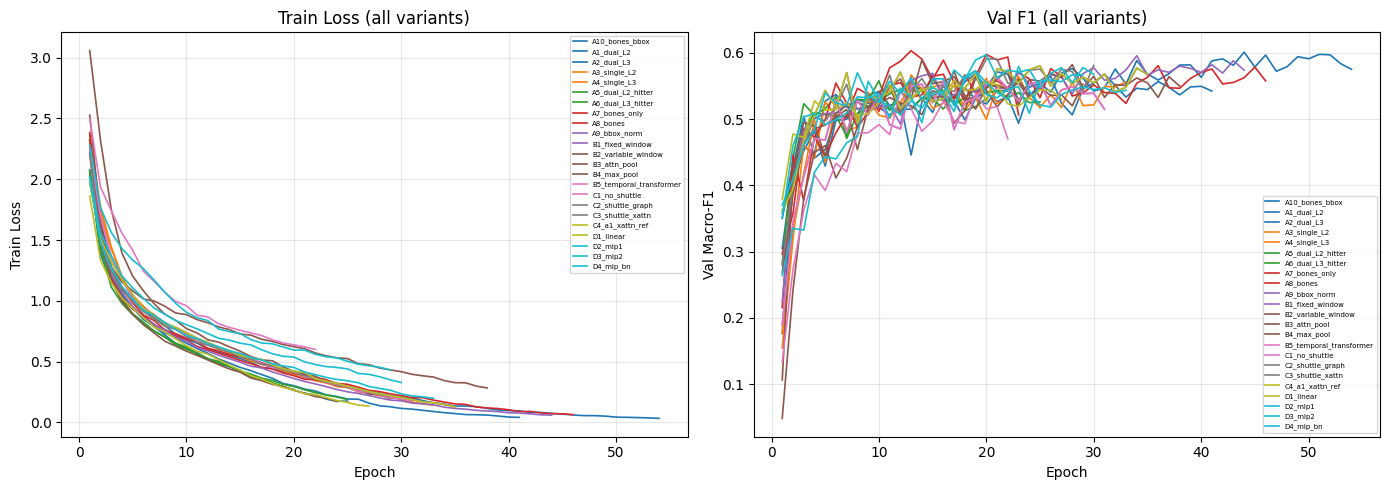

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/overfitting_analysis.png


In [22]:
# ── 8d — Overfitting Analysis ─────────────────────────────────────────────
# Reads JSON history only — no model or dataset needed.

all_res = {}
for p in sorted(ABLATION_DIR.glob('*.json')):
    if p.stem.startswith('_'): continue
    try: all_res[p.stem] = json.load(open(p))
    except: pass
print(f'Loaded {len(all_res)} result files')

print(f'\n{"Name":<30} {"Ep":>4} {"FinalLoss":>10} {"BestValF1":>10} {"TestF1":>8} {"Gap":>8}')
print('-' * 78)
for nm in sorted(all_res):
    r = all_res[nm]
    if not isinstance(r, dict):
        continue
    h = r.get('history', {})
    fl  = h['train_loss'][-1] if h.get('train_loss') else None
    bv  = r.get('best_val_f1'); tf = r.get('macro_f1')
    gap = bv - tf if bv is not None and tf is not None else None
    print(f'{nm:<30} {r["stopped_epoch"]:>4} '
          f'{"%10.4f" % fl if fl is not None else "%11s" % "N/A"} '
          f'{"%10.4f" % bv if bv is not None else "%11s" % "N/A"} '
          f'{"%8.4f" % tf if tf is not None else "%9s" % "N/A"} '
          f'{"%+8.4f" % gap if gap is not None else "N/A"}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
_colors = plt.cm.tab10(np.linspace(0, 1, max(len(all_res), 1)))
for (nm, r), c in zip(sorted(all_res.items()), _colors):
    h = r.get('history', {})
    if h.get('train_loss'):
        ax1.plot(range(1, len(h['train_loss'])+1), h['train_loss'], label=nm, color=c, lw=1.2)
    if h.get('val_f1'):
        ax2.plot(range(1, len(h['val_f1'])+1), h['val_f1'], label=nm, color=c, lw=1.2)
ax1.set(xlabel='Epoch', ylabel='Train Loss', title='Train Loss (all variants)')
ax2.set(xlabel='Epoch', ylabel='Val Macro-F1', title='Val F1 (all variants)')
for ax in (ax1, ax2): ax.legend(fontsize=5); ax.grid(True, alpha=0.3)
plt.tight_layout()
out = ABLATION_DIR / 'overfitting_analysis.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

In [24]:
# ── 8e — Diagnostic Summary ───────────────────────────────────────────────
# Depends on: _pairs (8a), tr_cnt (8b), _pct (8c), all_res (8d)

best_res = json.load(open(ABLATION_DIR / f'{fc["winner_name"]}.json'))
print('=' * 70)
print('DIAGNOSTIC SUMMARY')
print('=' * 70)
print(f'\n1. BEST CONFIG: {fc["winner_name"]}')
print(f'   Test Macro-F1: {best_res["macro_f1"]:.4f}')
print(f'   Test Accuracy: {best_res["accuracy"]:.4f}')
print(f'   Top-3 Acc:     {best_res.get("top3_acc", "N/A")}')
print(f'   Top-5 Acc:     {best_res.get("top5_acc", "N/A")}')
print(f'\n2. CONFIG FLAGS:')
for k, v in fc.items():
    print(f'   {k}: {v}')
print(f'\n3. CLASS IMBALANCE:')
print(f'   Largest: {max(tr_cnt.values())}  Smallest: {min(tr_cnt.values())}  '
      f'Ratio: {max(tr_cnt.values())/min(tr_cnt.values()):.1f}x')
print(f'\n4. SHUTTLE COVERAGE: {_pct:.1f}% of samples have trajectory data')
print(f'\n5. TOP 5 CONFUSION PAIRS:')
for cnt, frac, tc, pc in _pairs[:5]:
    print(f'   {tc} → {pc}: {cnt} ({frac:.0%})')
print(f'\n6. WORST CLASSES BY F1:')
_pc   = best_res.get('per_class', {})
_cf1s = [(v.get('f1-score', 0), v.get('support', 0), k) for k, v in _pc.items()
         if k not in ('accuracy', 'macro avg', 'weighted avg')]
for f1, sup, nm in sorted(_cf1s)[:5]:
    print(f'   {nm:<24} F1={f1:.2f}  (n={sup})')
_h = best_res.get('history', {})
if _h.get('train_loss'):
    bv = best_res['best_val_f1']; tf = best_res['macro_f1']
    print(f'\n7. OVERFITTING:')
    print(f'   Final train loss: {_h["train_loss"][-1]:.4f}')
    print(f'   Best val F1:      {bv:.4f}')
    print(f'   Test F1:          {tf:.4f}')
    print(f'   Gap:              {bv-tf:+.4f} ({"OK" if abs(bv-tf)<0.03 else "notable"})')
print(f'\n8. EVALUATION CAVEAT:')
print(f'   Test set = 2 matches ({len(y_true)} shots). Differences < 0.02 F1 may not be reliable.')
print(f'   Run §9 cross-validation (in run6 notebook) for robust estimates.')

DIAGNOSTIC SUMMARY

1. BEST CONFIG: C3_shuttle_xattn
   Test Macro-F1: 0.6462
   Test Accuracy: 0.7037
   Top-3 Acc:     0.9355
   Top-5 Acc:     0.976

2. CONFIG FLAGS:
   winner_name: C3_shuttle_xattn
   feature_layer: L3
   single_player: True
   use_hitter: False
   use_bones: False
   use_bbox_norm: False
   pooling: mean
   variable_window: False
   use_shuttle: True
   shuttle_fusion: cross_attn
   in_channels: 14
   num_nodes: 17

3. CLASS IMBALANCE:
   Largest: 2872  Smallest: 100  Ratio: 28.7x

4. SHUTTLE COVERAGE: 87.0% of samples have trajectory data

5. TOP 5 CONFUSION PAIRS:
   push → lob: 99 (44%)
   wrist smash → smash: 32 (43%)
   net shot → cross-court net shot: 25 (8%)
   smash → wrist smash: 18 (17%)
   drop → passive drop: 16 (26%)

6. WORST CLASSES BY F1:
   defensive return lob     F1=0.27  (n=8.0)
   wrist smash              F1=0.42  (n=75.0)
   drive                    F1=0.51  (n=106.0)
   cross-court net shot     F1=0.55  (n=63.0)
   drop                     

## §9 — Cross-Attention Weight Visualization

For §5.4 (Group C, shuttle fusion): show *where in the shot window* the cross-attention head looks per shot type. The query is a single token (skeleton embedding), so each shot produces one length-T attention distribution over the shuttle context.

**Expected pattern** if attention is doing real work: smash/drop peak near contact (t=16); clear/drive spread out. A uniform pattern across types would mean the +2.6 F1 from cross-attn comes from feature presence, not learned routing.

Requires §8a to have loaded a cross-attn winner (`ca` is not `None`).

In [28]:
# §9a — Capture per-sample cross-attention weights ─────────────────────
# Reads attention weights via a forward hook on the MultiheadAttention
# submodule (ca.cross_attn). This works with the *unmodified* model file:
# nn.MultiheadAttention returns (attn_output, attn_weights) by default, and
# the hook grabs the weights the model otherwise discards.

assert ca is not None, (
    "Cross-attention model not loaded — current config does not use "
    "shuttle_fusion='cross_attn'. Re-run §8a with a cross-attn winner first."
)


def _collect_attn(encoder, head_, cross_attn, ds):
    """Return list of dicts {label, pred, attn[T], shuttle[2,T], all_masked, frame_num}."""
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=collate_fn_shuttle)
    encoder.eval(); head_.eval(); cross_attn.eval()

    # Forward hook on the inner MHA — output is (attn_output, attn_weights),
    # weights shape (B, 1, T) averaged over heads.
    _cap = {}
    def _hook(_module, _inp, out):
        _cap['w'] = out[1].detach().cpu()
    handle = cross_attn.cross_attn.register_forward_hook(_hook)

    raw_samples = ds.ds.samples if hasattr(ds, 'ds') else ds.samples
    rows, cursor = [], 0
    try:
        with torch.no_grad():
            for xb, yb, sb in loader:
                valid = yb >= 0
                if valid.any():
                    xv = xb[valid].to(device)
                    sv = sb[valid].to(device)
                    yv = yb[valid]
                    emb   = encoder(xv)
                    _cap.clear()
                    fused = cross_attn(emb, sv)
                    preds = head_(fused).argmax(1).cpu().numpy()
                    # Per-sample "no shuttle data" flag (all positions zero).
                    masked = (sv.abs().sum(dim=1) == 0).all(dim=1).cpu().numpy()
                    if 'w' in _cap:
                        attn = _cap['w'].squeeze(1).numpy()        # (Bv, T)
                    else:
                        # Whole batch all-masked → model short-circuits, MHA never runs.
                        attn = np.zeros((int(valid.sum()), sv.shape[-1]))
                    v_pos = torch.nonzero(valid, as_tuple=False).flatten().tolist()
                    for j, pos in enumerate(v_pos):
                        samp = raw_samples[cursor + pos]
                        rows.append({
                            'label':       int(yv[j]),
                            'pred':        int(preds[j]),
                            'attn':        attn[j],
                            'shuttle':     sb[pos].numpy(),
                            'all_masked':  bool(masked[j]),
                            'frame_num':   int(samp.get('frame_num', 0)) if isinstance(samp, dict) else 0,
                            'rally_key':   samp.get('rally_key', '')   if isinstance(samp, dict) else '',
                        })
                cursor += len(yb)
    finally:
        handle.remove()
    return rows


attn_rows = _collect_attn(enc, head, ca, test_ds)
_n_total   = len(attn_rows)
_n_masked  = sum(r['all_masked'] for r in attn_rows)
print(f'Collected attention for {_n_total} samples '
      f'({_n_total - _n_masked} with shuttle data, {_n_masked} all-masked)')


Collected attention for 1627 samples (1613 with shuttle data, 14 all-masked)


#9b attention archive

Target class indices: {'smash': 2, 'drop': 8, 'drive': 7, 'clear': 6, 'defensive lob': None}
Selected 4/5 shot types with usable data


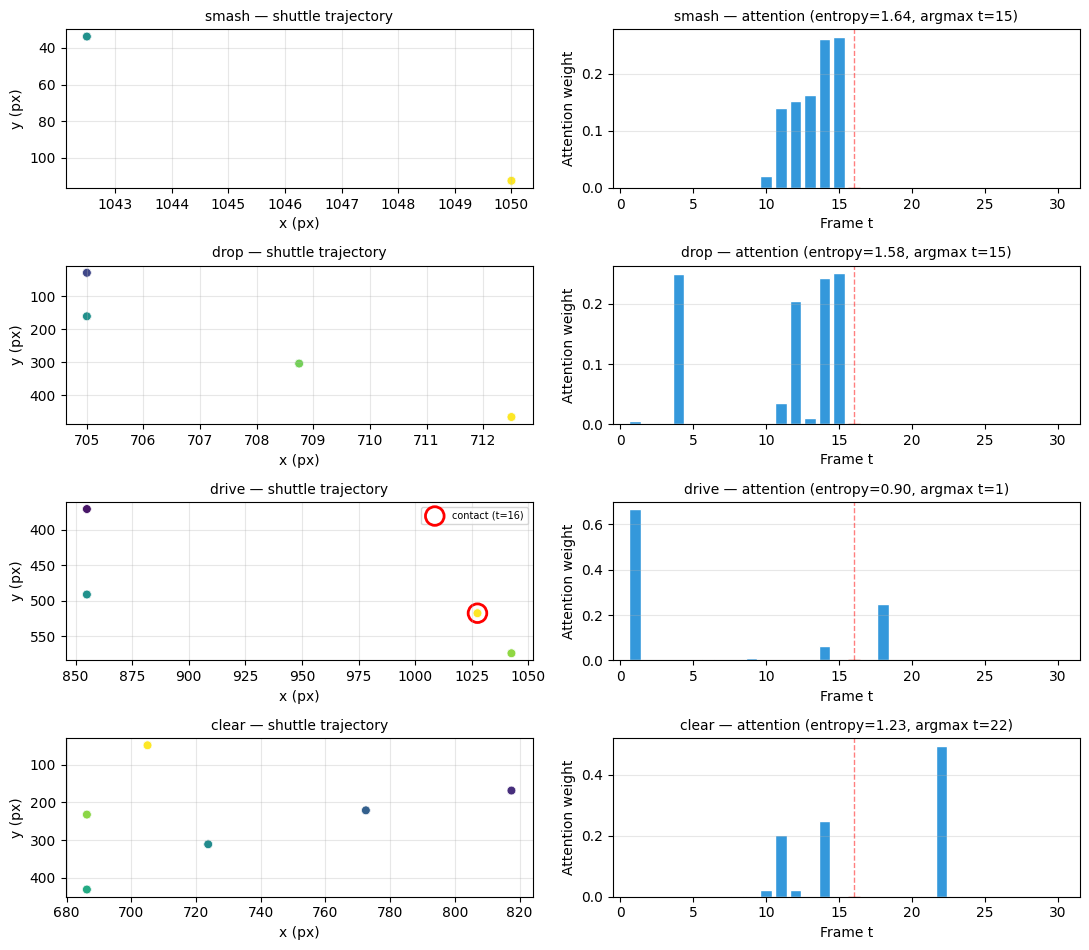

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/cross_attn_visualization.png

Shot type                  n  argmax t    peak  @contact   entropy
----------------------------------------------------------------
smash                    107        14   0.069     0.021     3.354
drop                      61        29   0.067     0.025     3.378
drive                    106        30   0.084     0.020     3.217
clear                    129        29   0.110     0.012     3.257


In [29]:
# ── §9b — Per-shot-type small multiples ──────────────────────────────────
# Empirical claim for §5.4: cross-attention learns *when* the shuttle is
# discriminative. If attention concentrates near contact (t=16) for smash/drop
# and spreads out for clear/drive, the +2.6 F1 reflects learned routing rather
# than mere feature presence.

TARGET_TYPES   = ['smash', 'drop', 'drive', 'clear', 'defensive lob']
CONTACT_FRAME  = SHOT_WINDOW // 2  # t=16

_name_to_id = {n.lower(): i for i, n in enumerate(SHOT_TYPES)}
target_ids  = {n: _name_to_id.get(n.lower()) for n in TARGET_TYPES}
print('Target class indices:', target_ids)


def _entropy(p):
    p = np.asarray(p) + 1e-12
    return -float((p * np.log(p)).sum())


# Pick one representative shot per type: correct prediction + shuttle data,
# sorted by lowest attention entropy (sharpest peak — most informative figure).
selected = {}
for name, cid in target_ids.items():
    if cid is None:
        continue
    cands = [r for r in attn_rows
             if r['label'] == cid and r['pred'] == cid and not r['all_masked']]
    if not cands:
        cands = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if not cands:
        continue
    cands.sort(key=lambda r: _entropy(r['attn']))
    selected[name] = cands[0]
print(f'Selected {len(selected)}/{len(TARGET_TYPES)} shot types with usable data')

rows_present = [n for n in TARGET_TYPES if n in selected]
n_rows = len(rows_present)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for i, name in enumerate(rows_present):
    r  = selected[name]
    sh = r['shuttle']  # (2, T)
    a  = r['attn']     # (T,)
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)

    ax = axes[i, 0]
    if visible.any():
        ax.scatter(xs[visible], ys[visible],
                   c=np.where(visible)[0], cmap='viridis',
                   s=40, edgecolors='white', linewidths=0.5)
        if visible[CONTACT_FRAME]:
            ax.scatter(xs[CONTACT_FRAME], ys[CONTACT_FRAME],
                       facecolors='none', edgecolors='red',
                       s=180, lw=2, label=f'contact (t={CONTACT_FRAME})')
            ax.legend(loc='upper right', fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'{name} — shuttle trajectory', fontsize=10)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    bars = ax.bar(range(SHOT_WINDOW), a, color='#3498db', edgecolor='white')
    bars[CONTACT_FRAME].set_color('#e74c3c')
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.5, lw=1)
    ax.set_title(
        f'{name} — attention (entropy={_entropy(a):.2f}, argmax t={int(a.argmax())})',
        fontsize=10,
    )
    ax.set_xlabel('Frame t'); ax.set_ylabel('Attention weight')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
out = ABLATION_DIR / 'cross_attn_visualization.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

# Aggregate over the whole test set: is the per-type pattern systematic?
print(f'\n{"Shot type":<22} {"n":>5} {"argmax t":>9} {"peak":>7} {"@contact":>9} {"entropy":>9}')
print('-' * 64)
for name, cid in target_ids.items():
    if cid is None:
        continue
    rs = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if not rs:
        print(f'{name:<22} {"0":>5}  (no samples with shuttle data)')
        continue
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)
    print(f'{name:<22} {len(rs):>5} {int(mean_a.argmax()):>9} '
          f'{mean_a.max():>7.3f} {mean_a[CONTACT_FRAME]:>9.3f} {_entropy(mean_a):>9.3f}')


Target class indices: {'smash': 2, 'drop': 8, 'drive': 7, 'clear': 6, 'defensive return lob': 5}


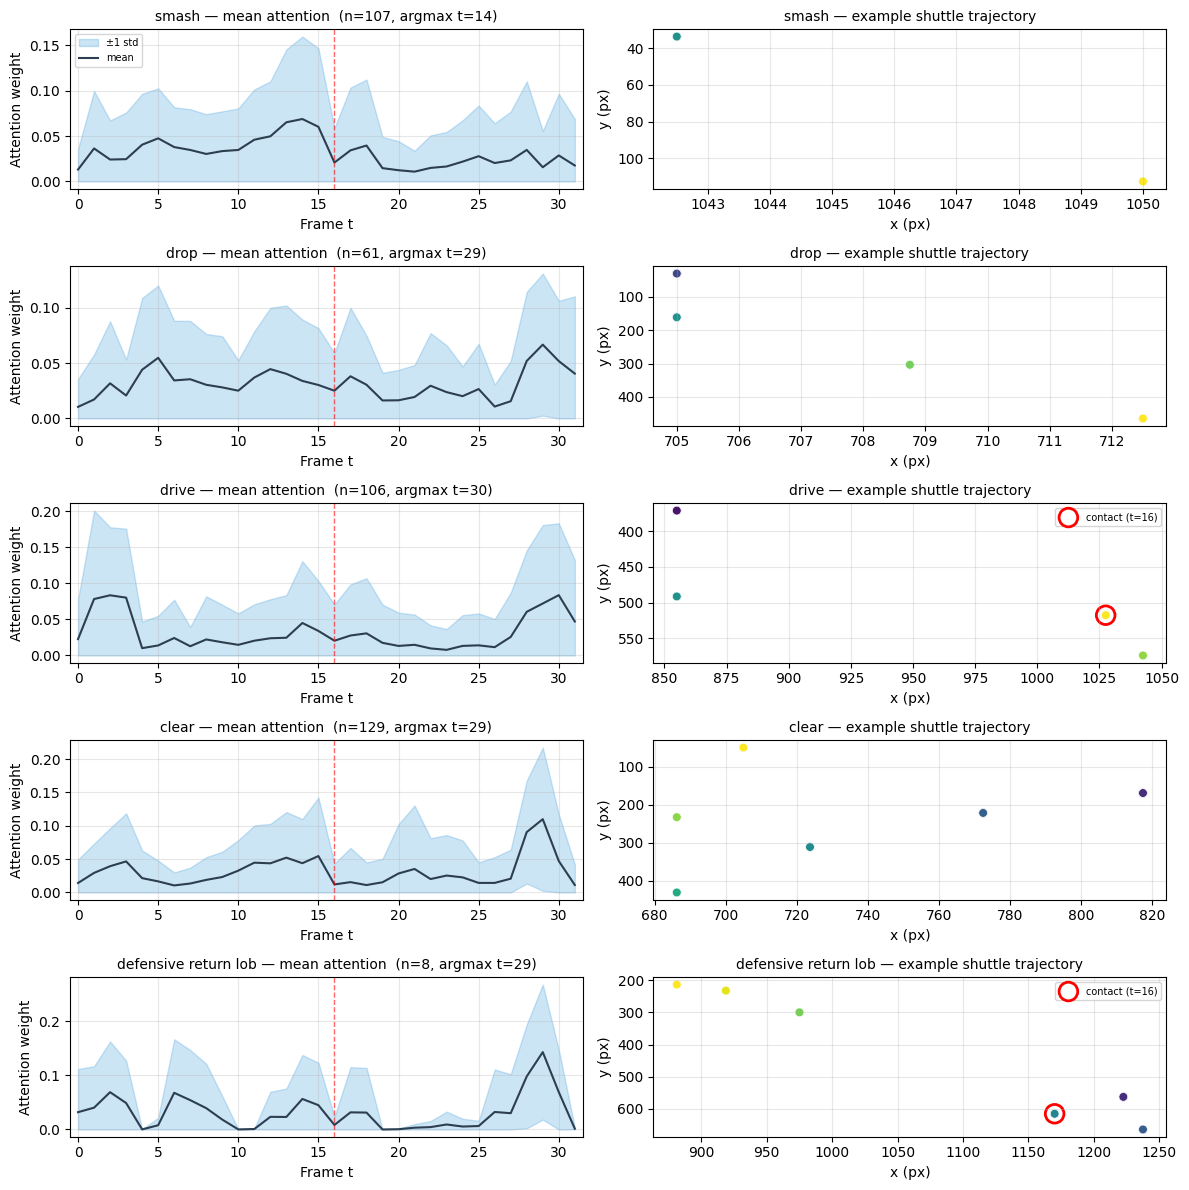

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/cross_attn_visualization.png

Shot type                    n  argmax t    peak  @contact   entropy
------------------------------------------------------------------
smash                      107        14   0.069     0.021     3.354
drop                        61        29   0.067     0.025     3.378
drive                      106        30   0.084     0.020     3.217
clear                      129        29   0.110     0.012     3.257
defensive return lob         8        29   0.143     0.008     2.957


In [31]:
# ── §9b — Mean attention per shot type (robust figure for §5.4) ──────────
# A single cherry-picked shot is an anecdote and is FP-fragile: tiny float
# differences across runs/environments reorder the "lowest-entropy" pick.
# The paper figure is the MEAN attention curve over ALL test shots of each
# type — does attention concentrate near contact (t=16) for smash/drop and
# spread out for clear/drive? An example trajectory is shown alongside for
# context, with a deterministic (stable-tiebreak) selection.

TARGET_TYPES   = ['smash', 'drop', 'drive', 'clear', 'defensive return lob']
CONTACT_FRAME  = SHOT_WINDOW // 2  # t=16

_name_to_id = {n.lower(): i for i, n in enumerate(SHOT_TYPES)}
target_ids  = {n: _name_to_id.get(n.lower()) for n in TARGET_TYPES}
print('Target class indices:', target_ids)


def _entropy(p):
    p = np.asarray(p) + 1e-12
    return -float((p * np.log(p)).sum())


# Group test-set attention by shot type (exclude all-masked = no shuttle data).
by_type = {}
for name, cid in target_ids.items():
    if cid is None:
        print(f'  [skip] {name!r} not found in SHOT_TYPES')
        continue
    rs = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if rs:
        by_type[name] = rs

rows_present = [n for n in TARGET_TYPES if n in by_type]
n_rows = len(rows_present)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 2.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

t = np.arange(SHOT_WINDOW)
for i, name in enumerate(rows_present):
    rs     = by_type[name]
    A      = np.stack([r['attn'] for r in rs])       # (n, T)
    mean_a = A.mean(0)
    std_a  = A.std(0)

    # col 0 — mean attention ± std over all test shots of this type
    ax = axes[i, 0]
    ax.fill_between(t, np.clip(mean_a - std_a, 0, None), mean_a + std_a,
                    color='#3498db', alpha=0.25, label='±1 std')
    ax.plot(t, mean_a, color='#2c3e50', lw=1.5, label='mean')
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.6, lw=1)
    ax.set_title(f'{name} — mean attention  (n={len(rs)}, '
                 f'argmax t={int(mean_a.argmax())})', fontsize=10)
    ax.set_xlabel('Frame t'); ax.set_ylabel('Attention weight')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

    # col 1 — one representative shot. Deterministic: sharpest (lowest-entropy)
    # attention, with a stable tiebreak so the pick doesn't wobble across runs.
    corr = [r for r in rs if r['pred'] == r['label']] or rs
    ex   = sorted(corr, key=lambda r: (round(_entropy(r['attn']), 3),
                                       r['frame_num'], r['rally_key']))[0]
    sh   = ex['shuttle']
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)
    ax = axes[i, 1]
    if visible.any():
        ax.scatter(xs[visible], ys[visible], c=np.where(visible)[0],
                   cmap='viridis', s=40, edgecolors='white', linewidths=0.5)
        if visible[CONTACT_FRAME]:
            ax.scatter(xs[CONTACT_FRAME], ys[CONTACT_FRAME], facecolors='none',
                       edgecolors='red', s=180, lw=2, label=f'contact (t={CONTACT_FRAME})')
            ax.legend(loc='upper right', fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'{name} — example shuttle trajectory', fontsize=10)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = ABLATION_DIR / 'cross_attn_visualization.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

# Aggregate table — is the per-type pattern systematic?
print(f'\n{"Shot type":<24} {"n":>5} {"argmax t":>9} {"peak":>7} {"@contact":>9} {"entropy":>9}')
print('-' * 66)
for name in rows_present:
    rs     = by_type[name]
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)
    print(f'{name:<24} {len(rs):>5} {int(mean_a.argmax()):>9} '
          f'{mean_a.max():>7.3f} {mean_a[CONTACT_FRAME]:>9.3f} {_entropy(mean_a):>9.3f}')

Target class indices: {'smash': 2, 'drop': 8, 'drive': 7, 'clear': 6, 'defensive return lob': 5}


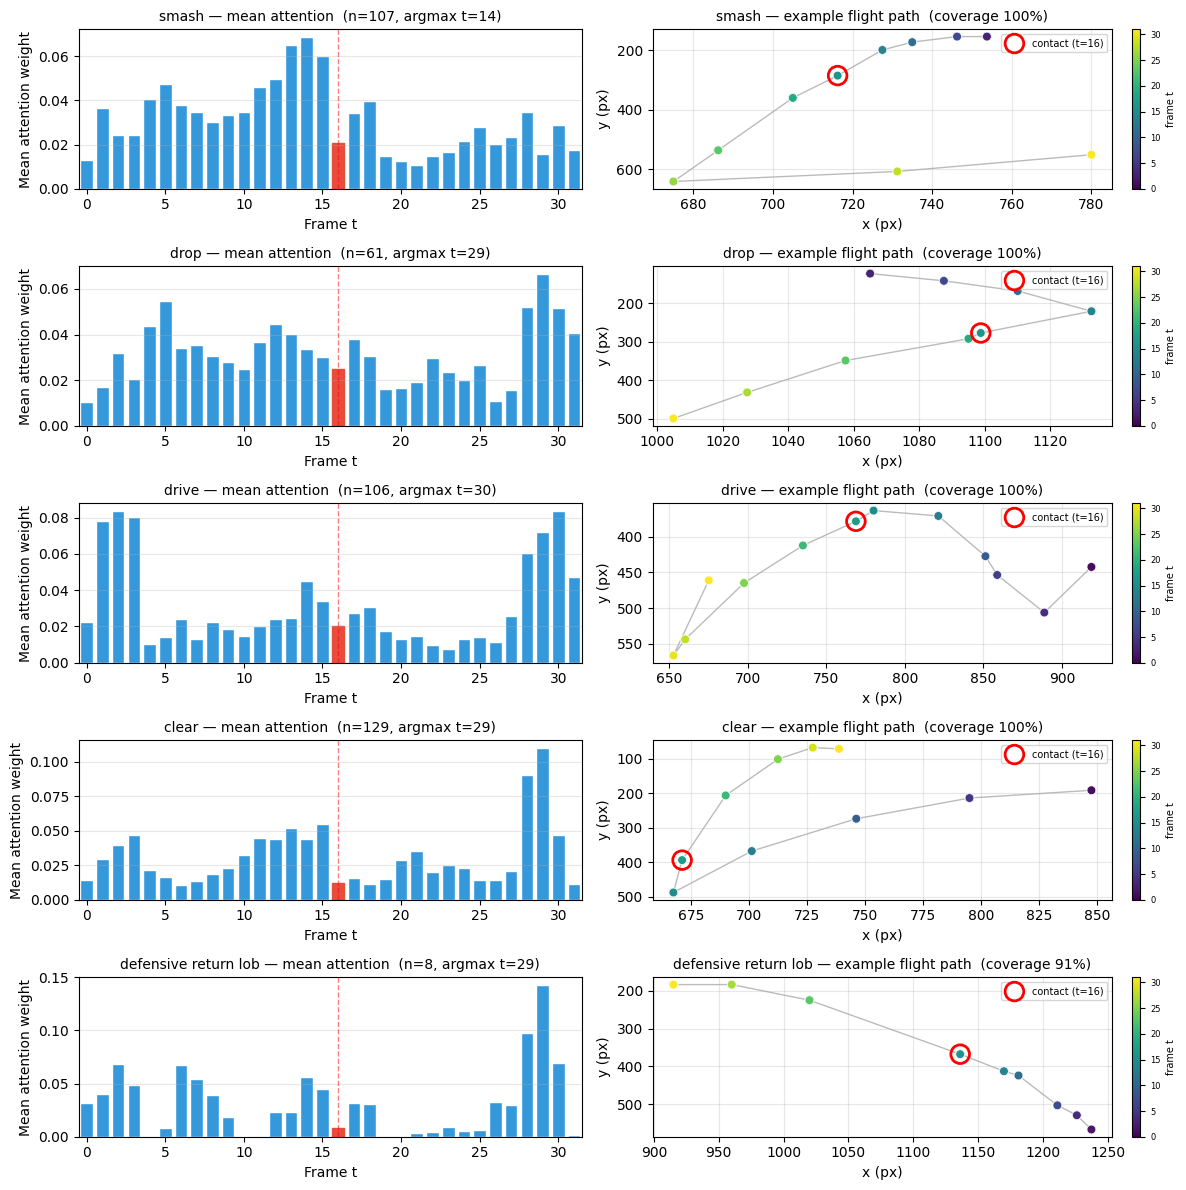

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/cross_attn_visualization.png

Shot type                    n  argmax t    peak  @contact   entropy
------------------------------------------------------------------
smash                      107        14   0.069     0.021     3.354
drop                        61        29   0.067     0.025     3.378
drive                      106        30   0.084     0.020     3.217
clear                      129        29   0.110     0.012     3.257
defensive return lob         8        29   0.143     0.008     2.957


In [33]:
# ── §9b — Mean attention per shot type + example flight path ─────────────
# Left  : MEAN attention over ALL test shots of each type (robust §5.4 figure)
#         — does attention concentrate near contact (t=16) for smash/drop and
#         spread out for clear/drive?
# Right : one example shuttle flight path, selected for HIGH tracking coverage
#         + correct prediction so the trajectory SHAPE is visible.
#         (The old "lowest-entropy" pick was biased — entropy correlates with
#         shuttle coverage at r=+0.59, so it kept choosing near-empty paths.)

TARGET_TYPES  = ['smash', 'drop', 'drive', 'clear', 'defensive return lob']
CONTACT_FRAME = SHOT_WINDOW // 2  # t=16

_name_to_id = {n.lower(): i for i, n in enumerate(SHOT_TYPES)}
target_ids  = {n: _name_to_id.get(n.lower()) for n in TARGET_TYPES}
print('Target class indices:', target_ids)


def _entropy(p):
    p = np.asarray(p) + 1e-12
    return -float((p * np.log(p)).sum())


def _coverage(sh):
    """Fraction of the T-frame window where the shuttle was tracked."""
    xs, ys = sh[0], sh[1]
    return float(((xs != 0) | (ys != 0)).mean())


# Group test-set attention by shot type (exclude all-masked = no shuttle data).
by_type = {}
for name, cid in target_ids.items():
    if cid is None:
        print(f'  [skip] {name!r} not found in SHOT_TYPES')
        continue
    rs = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if rs:
        by_type[name] = rs

rows_present = [n for n in TARGET_TYPES if n in by_type]
n_rows = len(rows_present)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 2.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

t = np.arange(SHOT_WINDOW)
for i, name in enumerate(rows_present):
    rs     = by_type[name]
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)   # (T,)

    # col 0 — MEAN attention over all test shots of this type (bar style)
    ax = axes[i, 0]
    bars = ax.bar(t, mean_a, color='#3498db', edgecolor='white')
    bars[CONTACT_FRAME].set_color('#e74c3c')
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.5, lw=1)
    ax.set_title(f'{name} — mean attention  (n={len(rs)}, '
                 f'argmax t={int(mean_a.argmax())})', fontsize=10)
    ax.set_xlabel('Frame t'); ax.set_ylabel('Mean attention weight')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3, axis='y')

    # col 1 — example flight path: highest tracking coverage among correctly
    # predicted shots, stable tiebreak so the pick is reproducible.
    cands = [r for r in rs if r['pred'] == r['label']] or rs
    ex = sorted(cands, key=lambda r: (-_coverage(r['shuttle']),
                                      r['frame_num'], r['rally_key']))[0]
    sh = ex['shuttle']
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)
    ax = axes[i, 1]
    if visible.any():
        vi = np.where(visible)[0]
        ax.plot(xs[vi], ys[vi], '-', color='#bbbbbb', lw=1, zorder=1)
        sc = ax.scatter(xs[vi], ys[vi], c=vi, cmap='viridis', vmin=0,
                        vmax=SHOT_WINDOW - 1, s=40, edgecolors='white',
                        linewidths=0.5, zorder=2)
        if visible[CONTACT_FRAME]:
            ax.scatter(xs[CONTACT_FRAME], ys[CONTACT_FRAME], facecolors='none',
                       edgecolors='red', s=180, lw=2, zorder=3,
                       label=f'contact (t={CONTACT_FRAME})')
            ax.legend(loc='upper right', fontsize=7)
        cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label('frame t', fontsize=7); cb.ax.tick_params(labelsize=6)
    ax.invert_yaxis()
    ax.set_title(f'{name} — example flight path  '
                 f'(coverage {_coverage(sh):.0%})', fontsize=10)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = ABLATION_DIR / 'cross_attn_visualization.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

# Aggregate table — is the per-type pattern systematic?
print(f'\n{"Shot type":<24} {"n":>5} {"argmax t":>9} {"peak":>7} {"@contact":>9} {"entropy":>9}')
print('-' * 66)
for name in rows_present:
    rs     = by_type[name]
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)
    print(f'{name:<24} {len(rs):>5} {int(mean_a.argmax()):>9} '
          f'{mean_a.max():>7.3f} {mean_a[CONTACT_FRAME]:>9.3f} {_entropy(mean_a):>9.3f}')


#9b Mean Attention + Shuttle Height per shot type

Target class indices: {'smash': 2, 'return net': 1, 'clear': 6, 'lob': 4}


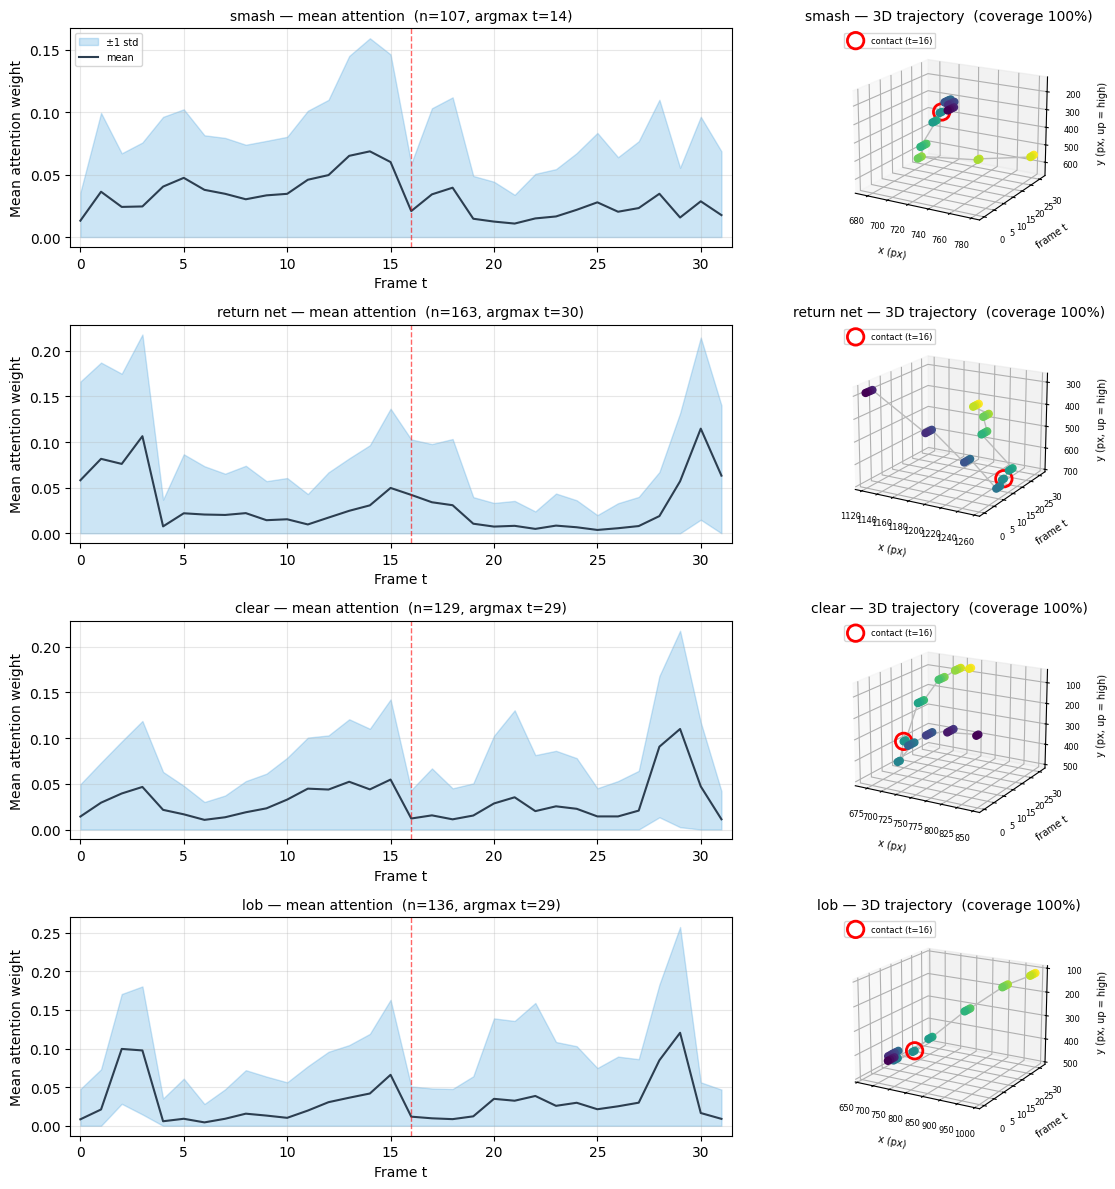

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/cross_attn_visualization.png

Shot type                    n  argmax t    peak  @contact   entropy
------------------------------------------------------------------
smash                      107        14   0.069     0.021     3.354
return net                 163        30   0.115     0.042     3.082
clear                      129        29   0.110     0.012     3.257
lob                        136        29   0.120     0.012     3.104


In [35]:
# ── §9b — Mean attention + 3D shuttle trajectory per shot type ───────────
# Left  : MEAN attention over ALL test shots of each type (line + ±1 std band)
#         — does attention concentrate near contact (t=16)?
# Right : 3D shuttle trajectory for one example shot — axes are
#         (x pixel, frame t, y pixel). The frame axis unrolls the path over
#         time, so the incoming and outgoing arcs no longer overlap the way
#         they do in a flat 2D scatter. z (y-pixel) is inverted: up = high.
#         Example selected for highest tracking coverage (correct prediction).

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)

TARGET_TYPES  = ['smash', 'return net', 'clear', 'lob']  # §9c-validated: genuine routing
CONTACT_FRAME = SHOT_WINDOW // 2  # t=16

_name_to_id = {n.lower(): i for i, n in enumerate(SHOT_TYPES)}
target_ids  = {n: _name_to_id.get(n.lower()) for n in TARGET_TYPES}
print('Target class indices:', target_ids)


def _entropy(p):
    p = np.asarray(p) + 1e-12
    return -float((p * np.log(p)).sum())


def _coverage(sh):
    """Fraction of the T-frame window where the shuttle was tracked."""
    xs, ys = sh[0], sh[1]
    return float(((xs != 0) | (ys != 0)).mean())


# Group test-set attention by shot type (exclude all-masked = no shuttle data).
by_type = {}
for name, cid in target_ids.items():
    if cid is None:
        print(f'  [skip] {name!r} not found in SHOT_TYPES')
        continue
    rs = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if rs:
        by_type[name] = rs

rows_present = [n for n in TARGET_TYPES if n in by_type]
n_rows = len(rows_present)

t = np.arange(SHOT_WINDOW)
fig = plt.figure(figsize=(13, 3.0 * n_rows))

for i, name in enumerate(rows_present):
    rs     = by_type[name]
    A      = np.stack([r['attn'] for r in rs])           # (n, T)
    mean_a = A.mean(0)
    std_a  = A.std(0)

    # col 0 — MEAN attention ± std over all test shots of this type
    ax = fig.add_subplot(n_rows, 2, 2 * i + 1)
    ax.fill_between(t, np.clip(mean_a - std_a, 0, None), mean_a + std_a,
                    color='#3498db', alpha=0.25, label='±1 std')
    ax.plot(t, mean_a, color='#2c3e50', lw=1.5, label='mean')
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.6, lw=1)
    ax.set_title(f'{name} — mean attention  (n={len(rs)}, '
                 f'argmax t={int(mean_a.argmax())})', fontsize=10)
    ax.set_xlabel('Frame t'); ax.set_ylabel('Mean attention weight')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

    # col 1 — 3D trajectory (x pixel, frame t, y pixel) for one example shot.
    # Highest coverage among correct predictions; stable tiebreak = reproducible.
    cands = [r for r in rs if r['pred'] == r['label']] or rs
    ex = sorted(cands, key=lambda r: (-_coverage(r['shuttle']),
                                      r['frame_num'], r['rally_key']))[0]
    sh = ex['shuttle']
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)
    ax = fig.add_subplot(n_rows, 2, 2 * i + 2, projection='3d')
    if visible.any():
        vi = np.where(visible)[0]
        ax.plot(xs[vi], vi, ys[vi], '-', color='#bbbbbb', lw=1)
        ax.scatter(xs[vi], vi, ys[vi], c=vi, cmap='viridis',
                   vmin=0, vmax=SHOT_WINDOW - 1, s=25, depthshade=False)
        if visible[CONTACT_FRAME]:
            ax.scatter([xs[CONTACT_FRAME]], [CONTACT_FRAME], [ys[CONTACT_FRAME]],
                       facecolors='none', edgecolors='red', s=140, lw=2,
                       label=f'contact (t={CONTACT_FRAME})')
            ax.legend(fontsize=6, loc='upper left')
    ax.set_xlabel('x (px)', fontsize=7)
    ax.set_ylabel('frame t', fontsize=7)
    ax.set_zlabel('y (px, up = high)', fontsize=7)
    ax.invert_zaxis()  # image y grows downward → invert so "up" = high in air
    ax.tick_params(labelsize=6)
    ax.view_init(elev=18, azim=-60)
    ax.set_title(f'{name} — 3D trajectory  (coverage {_coverage(sh):.0%})',
                 fontsize=10)

plt.tight_layout()
out = ABLATION_DIR / 'cross_attn_visualization.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

# Aggregate table — is the per-type pattern systematic?
print(f'\n{"Shot type":<24} {"n":>5} {"argmax t":>9} {"peak":>7} {"@contact":>9} {"entropy":>9}')
print('-' * 66)
for name in rows_present:
    rs     = by_type[name]
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)
    print(f'{name:<24} {len(rs):>5} {int(mean_a.argmax()):>9} '
          f'{mean_a.max():>7.3f} {mean_a[CONTACT_FRAME]:>9.3f} {_entropy(mean_a):>9.3f}')

Target class indices: {'smash': 2, 'drop': 8, 'drive': 7, 'clear': 6, 'defensive return lob': 5}


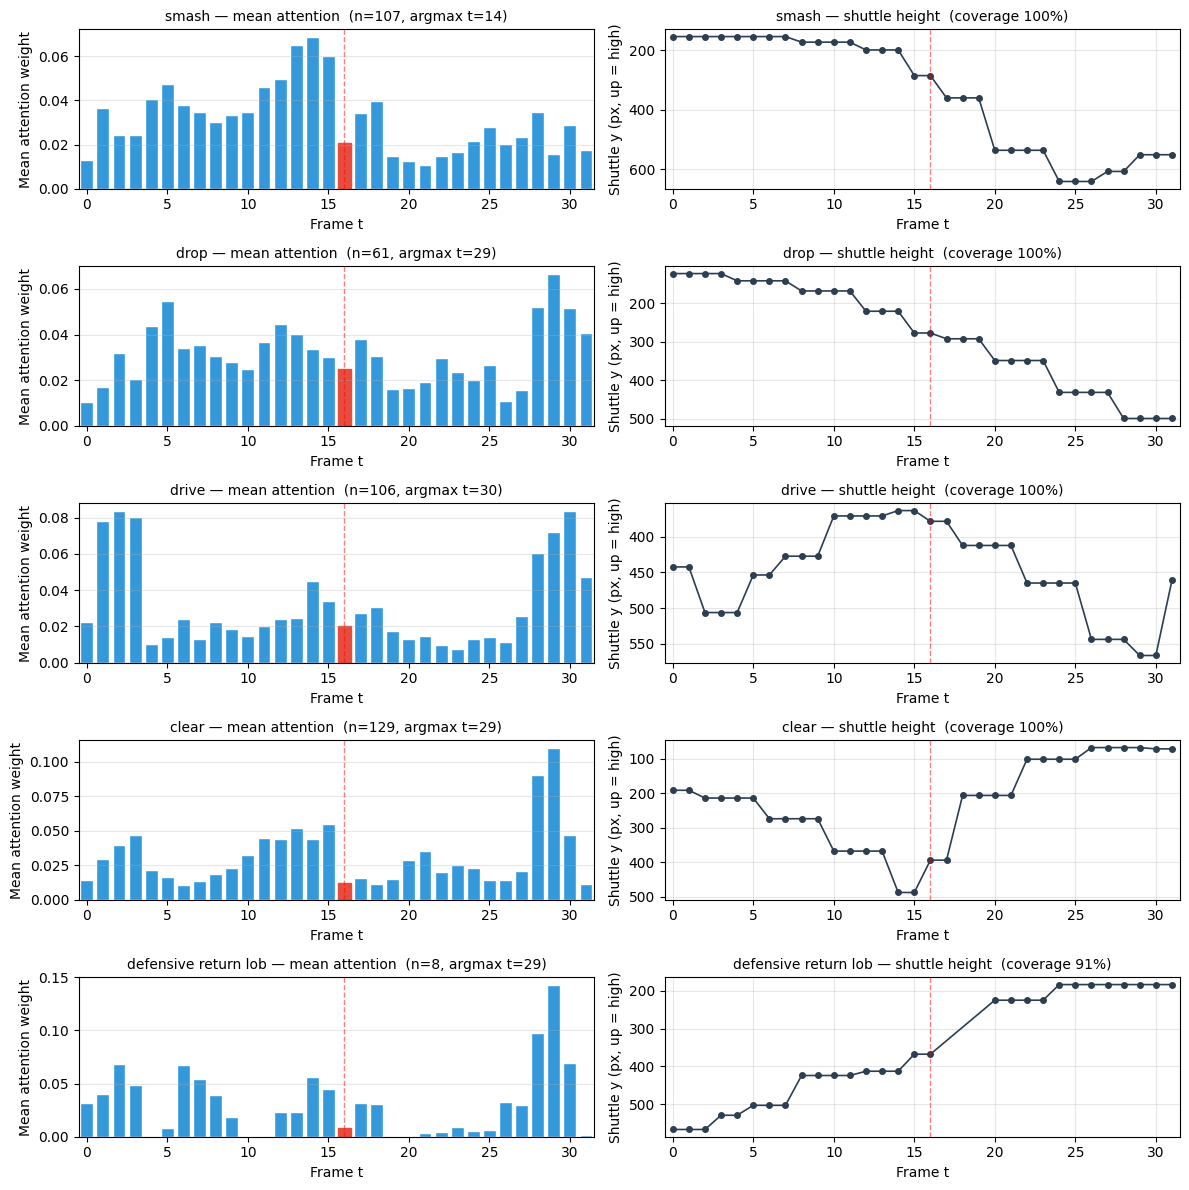

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/cross_attn_visualization.png

Shot type                    n  argmax t    peak  @contact   entropy
------------------------------------------------------------------
smash                      107        14   0.069     0.021     3.354
drop                        61        29   0.067     0.025     3.378
drive                      106        30   0.084     0.020     3.217
clear                      129        29   0.110     0.012     3.257
defensive return lob         8        29   0.143     0.008     2.957


In [34]:
# ── §9b — Mean attention + shuttle height per shot type ──────────────────
# Left  : MEAN attention over ALL test shots of each type (robust §5.4 figure)
#         — does attention concentrate near contact (t=16)?
# Right : shuttle HEIGHT over the shot window for one example. Same x-axis
#         (frame t) as the attention plot, so the two line up directly.
#         Height (inverted y-pixel: up = high in the air) makes shot shape
#         readable — smash drops steeply, clear arcs high, drive stays flat.
#         Example selected for highest tracking coverage (correct prediction).

TARGET_TYPES  = ['smash', 'drop', 'drive', 'clear', 'defensive return lob']
CONTACT_FRAME = SHOT_WINDOW // 2  # t=16

_name_to_id = {n.lower(): i for i, n in enumerate(SHOT_TYPES)}
target_ids  = {n: _name_to_id.get(n.lower()) for n in TARGET_TYPES}
print('Target class indices:', target_ids)


def _entropy(p):
    p = np.asarray(p) + 1e-12
    return -float((p * np.log(p)).sum())


def _coverage(sh):
    """Fraction of the T-frame window where the shuttle was tracked."""
    xs, ys = sh[0], sh[1]
    return float(((xs != 0) | (ys != 0)).mean())


# Group test-set attention by shot type (exclude all-masked = no shuttle data).
by_type = {}
for name, cid in target_ids.items():
    if cid is None:
        print(f'  [skip] {name!r} not found in SHOT_TYPES')
        continue
    rs = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if rs:
        by_type[name] = rs

rows_present = [n for n in TARGET_TYPES if n in by_type]
n_rows = len(rows_present)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 2.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

t = np.arange(SHOT_WINDOW)
for i, name in enumerate(rows_present):
    rs     = by_type[name]
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)   # (T,)

    # col 0 — MEAN attention over all test shots of this type (bar style)
    ax = axes[i, 0]
    bars = ax.bar(t, mean_a, color='#3498db', edgecolor='white')
    bars[CONTACT_FRAME].set_color('#e74c3c')
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.5, lw=1)
    ax.set_title(f'{name} — mean attention  (n={len(rs)}, '
                 f'argmax t={int(mean_a.argmax())})', fontsize=10)
    ax.set_xlabel('Frame t'); ax.set_ylabel('Mean attention weight')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3, axis='y')

    # col 1 — shuttle height vs frame for one well-tracked example shot.
    # Highest coverage among correct predictions; stable tiebreak = reproducible.
    cands = [r for r in rs if r['pred'] == r['label']] or rs
    ex = sorted(cands, key=lambda r: (-_coverage(r['shuttle']),
                                      r['frame_num'], r['rally_key']))[0]
    sh = ex['shuttle']
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)
    ax = axes[i, 1]
    if visible.any():
        vi = np.where(visible)[0]
        ax.plot(vi, ys[vi], '-o', color='#2c3e50', ms=4, lw=1.2)
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.5, lw=1)
    ax.invert_yaxis()  # image y grows downward → invert so "up" = high in air
    ax.set_title(f'{name} — shuttle height  (coverage {_coverage(sh):.0%})',
                 fontsize=10)
    ax.set_xlabel('Frame t'); ax.set_ylabel('Shuttle y (px, up = high)')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = ABLATION_DIR / 'cross_attn_visualization.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

# Aggregate table — is the per-type pattern systematic?
print(f'\n{"Shot type":<24} {"n":>5} {"argmax t":>9} {"peak":>7} {"@contact":>9} {"entropy":>9}')
print('-' * 66)
for name in rows_present:
    rs     = by_type[name]
    mean_a = np.stack([r['attn'] for r in rs]).mean(0)
    print(f'{name:<24} {len(rs):>5} {int(mean_a.argmax()):>9} '
          f'{mean_a.max():>7.3f} {mean_a[CONTACT_FRAME]:>9.3f} {_entropy(mean_a):>9.3f}')

Usable samples (≥1 visible frame): 1613 / 1627

Shot type             n   vis%   PRE  obs   null       Δ    CONT obs   null       Δ    POST obs   null       Δ
--------------------------------------------------------------------------------------------------------------
smash               107  72.5%      0.518  0.585  -0.067       0.223  0.151  +0.072       0.259  0.264  -0.005
drop                 61  85.8%      0.453  0.487  -0.034       0.158  0.150  +0.007       0.389  0.362  +0.027
drive               106  78.3%      0.450  0.468  -0.018       0.158  0.157  +0.001       0.392  0.375  +0.017
clear               129  87.3%      0.407  0.495  -0.087       0.137  0.141  -0.004       0.456  0.364  +0.092
lob                 136  74.1%      0.381  0.495  -0.114       0.138  0.112  +0.026       0.481  0.393  +0.088
net shot            295  75.4%      0.499  0.455  +0.044       0.115  0.122  -0.007       0.386  0.423  -0.036
passive drop         88  88.6%      0.441  0.490  -0.049       0

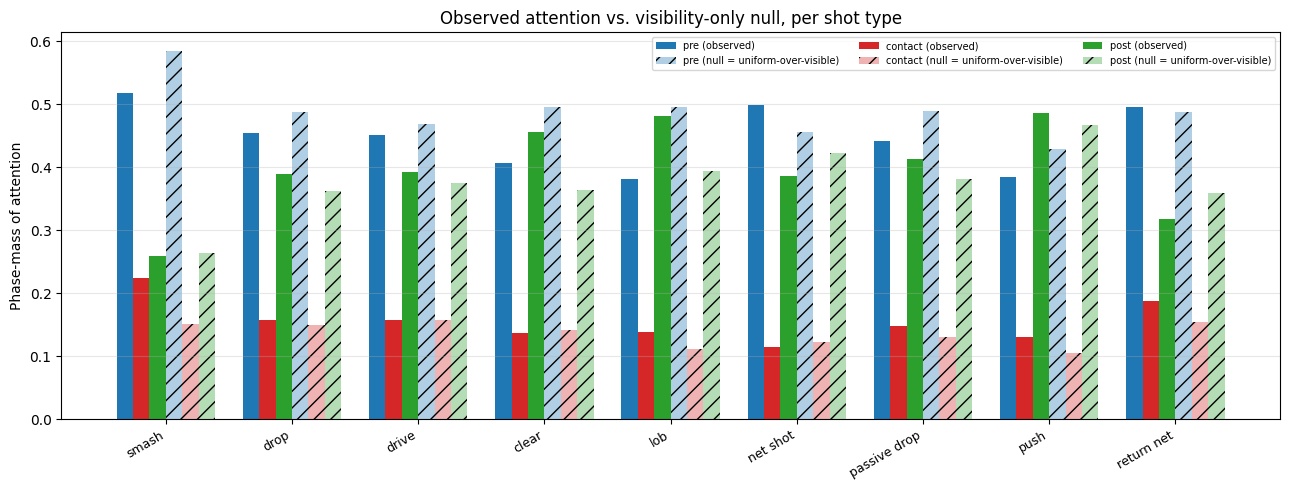

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/xattn_phase_mass.png


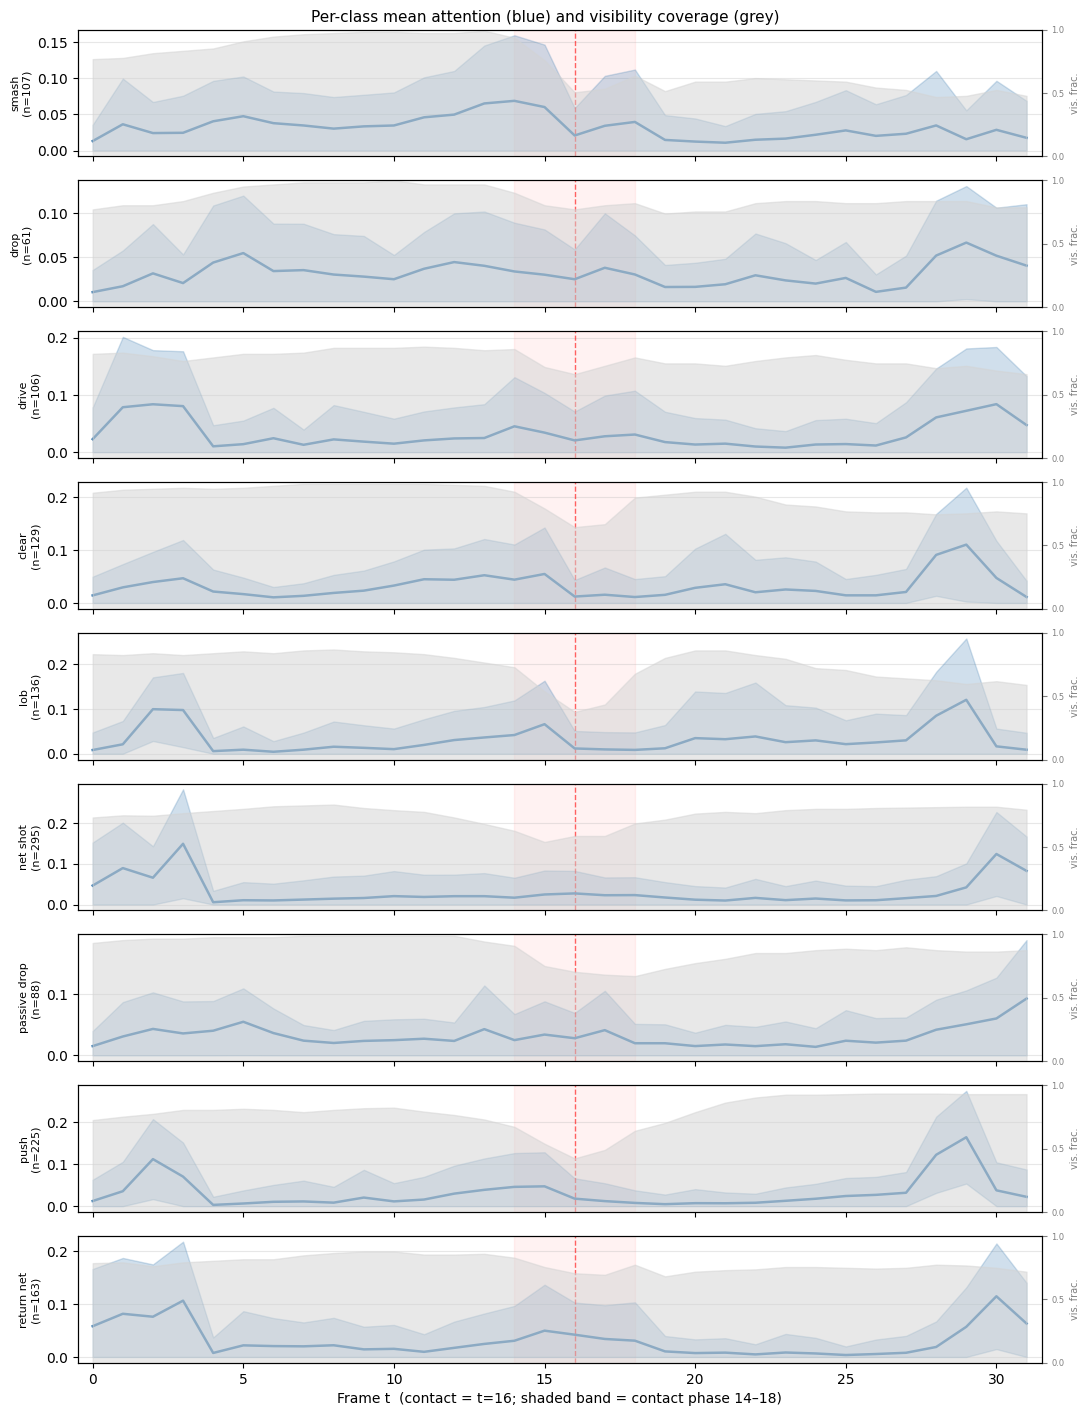

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/xattn_per_class_curves.png

Interpretation guide:
  Δ (contact) > +0.05  → model attends to contact MORE than visibility would predict
  Δ (contact) ≈   0    → contact peak is a visibility artefact
  Δ (post)    > +0.05  → learned routing toward outgoing trajectory (e.g. clear)
  Δ (pre)     > +0.05  → learned routing toward incoming context (e.g. drive)


In [32]:
# ── §9c — Learned routing vs. data availability ──────────────────────────
# For each test shot, partition the 32-frame window into:
#     pre-contact:   t ∈ [0, 14)          (14 frames)
#     contact:       t ∈ [14, 18]         ( 5 frames, hit ±2)
#     post-contact:  t ∈ (18, 32)         (13 frames)
# Then compare two quantities per class:
#   observed phase-mass = sum of attention weights in that phase
#   null phase-mass     = sum of *renormalised* visibility in that phase,
#                         i.e., what the model would put there if it attended
#                         uniformly to visible frames.
# Δ = observed − null is the learned routing component. Δ ≈ 0 ⇒ the bar charts
# in §9b are visibility artefacts; |Δ| meaningfully > 0 ⇒ real routing.

PHASES = {
    'pre':     np.arange(0, 14),
    'contact': np.arange(14, 19),     # t = 14..18 inclusive
    'post':    np.arange(19, SHOT_WINDOW),
}
TARGET_TYPES_AGG = ['smash', 'drop', 'drive', 'clear', 'lob', 'net shot',
                    'passive drop', 'push', 'return net']

# ── Per-sample stats ──────────────────────────────────────────────────────
def _phase_masses(weights):
    """Sum of `weights` in each of the three phases."""
    return {ph: float(weights[idx].sum()) for ph, idx in PHASES.items()}


per_sample = []
for r in attn_rows:
    if r['all_masked']:
        continue
    sh      = r['shuttle']                                 # (2, T)
    a       = r['attn'].astype(np.float64)                 # (T,)
    visible = (np.abs(sh).sum(axis=0) > 0).astype(np.float64)  # (T,)
    n_vis   = int(visible.sum())
    if n_vis == 0:
        continue

    # Null = uniform over visible frames (what attention would do if it
    # only obeyed the key-padding mask and learned nothing else).
    null = visible / n_vis

    per_sample.append({
        'label':    r['label'],
        'pred':     r['pred'],
        'n_vis':    n_vis,
        'obs':      _phase_masses(a),
        'null':     _phase_masses(null),
        'attn':     a,
        'visible':  visible,
    })

print(f'Usable samples (≥1 visible frame): {len(per_sample)} / {len(attn_rows)}')


# ── Per-class aggregate ───────────────────────────────────────────────────
def _agg(rows, key):
    """Mean over `rows` of the phase-mass dict at `row[key]`."""
    return {ph: float(np.mean([r[key][ph] for r in rows])) for ph in PHASES}


print(f'\n{"Shot type":<18} {"n":>4} {"vis%":>6}  '
      f'{"PRE  obs":>9} {"null":>6} {"Δ":>7}   '
      f'{"CONT obs":>9} {"null":>6} {"Δ":>7}   '
      f'{"POST obs":>9} {"null":>6} {"Δ":>7}')
print('-' * 110)

class_summary = {}
for name in TARGET_TYPES_AGG:
    cid = _name_to_id.get(name.lower())
    if cid is None:
        continue
    rs = [r for r in per_sample if r['label'] == cid]
    if not rs:
        continue
    obs  = _agg(rs, 'obs')
    null = _agg(rs, 'null')
    delta = {ph: obs[ph] - null[ph] for ph in PHASES}
    vis_pct = 100.0 * np.mean([r['n_vis'] for r in rs]) / SHOT_WINDOW
    class_summary[name] = {'n': len(rs), 'obs': obs, 'null': null,
                           'delta': delta, 'vis_pct': vis_pct, 'rows': rs}
    print(f'{name:<18} {len(rs):>4} {vis_pct:>5.1f}%  '
          f'{obs["pre"]:>9.3f} {null["pre"]:>6.3f} {delta["pre"]:>+7.3f}   '
          f'{obs["contact"]:>9.3f} {null["contact"]:>6.3f} {delta["contact"]:>+7.3f}   '
          f'{obs["post"]:>9.3f} {null["post"]:>6.3f} {delta["post"]:>+7.3f}')


# ── Figure 1: observed vs null phase mass per class (the headline plot) ──
fig, ax = plt.subplots(figsize=(13, 5))
names    = list(class_summary.keys())
x        = np.arange(len(names))
bar_w    = 0.13
offsets  = {'pre': -2.5, 'contact': -1.5, 'post': -0.5,
            'pre_n': 0.5, 'contact_n': 1.5, 'post_n': 2.5}
colors   = {'pre': '#1f77b4', 'contact': '#d62728', 'post': '#2ca02c'}

for ph in ['pre', 'contact', 'post']:
    obs_vals  = [class_summary[n]['obs'][ph]  for n in names]
    null_vals = [class_summary[n]['null'][ph] for n in names]
    ax.bar(x + offsets[ph]      * bar_w, obs_vals,  bar_w,
           color=colors[ph], label=f'{ph} (observed)')
    ax.bar(x + offsets[ph + '_n'] * bar_w, null_vals, bar_w,
           color=colors[ph], alpha=0.35, hatch='//',
           label=f'{ph} (null = uniform-over-visible)')

ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Phase-mass of attention')
ax.set_title('Observed attention vs. visibility-only null, per shot type')
ax.legend(ncol=3, fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
out1 = ABLATION_DIR / 'xattn_phase_mass.png'
plt.savefig(out1, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out1}')


# ── Figure 2: per-class mean attention curve + visibility band ──────────
n_cls = len(class_summary)
fig, axes = plt.subplots(n_cls, 1, figsize=(11, 1.6 * n_cls), sharex=True)
if n_cls == 1:
    axes = [axes]

for ax, (name, c) in zip(axes, class_summary.items()):
    attn_stack = np.stack([r['attn']    for r in c['rows']])     # (n, T)
    vis_stack  = np.stack([r['visible'] for r in c['rows']])     # (n, T)
    mean_attn  = attn_stack.mean(0)
    sd_attn    = attn_stack.std(0)
    vis_frac   = vis_stack.mean(0)         # fraction of class with shuttle visible at t

    ax2 = ax.twinx()
    ax2.fill_between(range(SHOT_WINDOW), 0, vis_frac,
                     color='lightgrey', alpha=0.5,
                     label='visibility fraction')
    ax2.set_ylim(0, 1); ax2.set_yticks([0, 0.5, 1])
    ax2.set_ylabel('vis. frac.', fontsize=7, color='grey')
    ax2.tick_params(axis='y', labelsize=6, colors='grey')

    ax.plot(range(SHOT_WINDOW), mean_attn, color='steelblue', lw=1.8, zorder=3)
    ax.fill_between(range(SHOT_WINDOW),
                    np.maximum(0, mean_attn - sd_attn),
                    mean_attn + sd_attn,
                    color='steelblue', alpha=0.25, zorder=2)
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.6, lw=1)
    ax.axvspan(14, 18, color='red', alpha=0.05, zorder=0)
    ax.set_ylabel(f'{name}\n(n={c["n"]})', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)

axes[-1].set_xlabel('Frame t  (contact = t=16; shaded band = contact phase 14–18)')
fig.suptitle('Per-class mean attention (blue) and visibility coverage (grey)',
             fontsize=11)
plt.tight_layout()
out2 = ABLATION_DIR / 'xattn_per_class_curves.png'
plt.savefig(out2, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out2}')


# ── Quick verbal verdict ──────────────────────────────────────────────────
print('\nInterpretation guide:')
print('  Δ (contact) > +0.05  → model attends to contact MORE than visibility would predict')
print('  Δ (contact) ≈   0    → contact peak is a visibility artefact')
print('  Δ (post)    > +0.05  → learned routing toward outgoing trajectory (e.g. clear)')
print('  Δ (pre)     > +0.05  → learned routing toward incoming context (e.g. drive)')
